
 ## Veri seti oluşturma
 - TRAIN / TEST altında DR1..DR8 diyalekt bölgeleri ve her bölgede konuşmacı klasörleri. - Her utterance için .WAV + .TXT + .PHN + .WRD

 Çıktı: code/csv_out/timit_train.csv, code/csv_out/timit_test.csv.

In [ ]:

from pathlib import Path
import json
import random

import numpy as np
import pandas as pd

DATA_ROOT = Path(r"C:\Users\engin\Desktop\TIMIT\data\lisa\data\timit\raw\TIMIT")
TRAIN_DIR = DATA_ROOT / "TRAIN"
TEST_DIR = DATA_ROOT / "TEST"

assert TRAIN_DIR.exists(), f"Yok: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Yok: {TEST_DIR}"

In [3]:
from typing import Optional


def read_txt_sentence(txt_path: Path) -> str:
    line = txt_path.read_text(encoding="utf-8", errors="ignore").strip().splitlines()[0]
    parts = line.split(maxsplit=2)
    if len(parts) < 3:
        return ""
    return parts[2].strip()


In [4]:
def read_segments(seg_path: Path):
    segs = []
    for line in seg_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line:
            continue
        start_s, end_s, label = line.split(maxsplit=2)
        segs.append({"start": int(start_s), "end": int(end_s), "label": label})
    return segs

In [5]:
def resolve_wav_path(txt_path: Path) -> Optional[Path]:
    cand = txt_path.with_suffix(".WAV")
    if cand.exists():
        return cand
    cand2 = txt_path.with_suffix(".wav")
    if cand2.exists():
        return cand2
    return None


In [6]:
def build_rows(split_dir: Path, split_name: str):
    rows = []
    for txt_path in split_dir.rglob("*.TXT"):
        stem = txt_path.with_suffix("").name
        phn_path = txt_path.with_suffix(".PHN")
        wrd_path = txt_path.with_suffix(".WRD")
        wav_path = resolve_wav_path(txt_path)

        if not phn_path.exists() or not wrd_path.exists():
            continue

        speaker_dir = txt_path.parent
        speaker_id = speaker_dir.name
        dr_id = speaker_dir.parent.name

        sentence = read_txt_sentence(txt_path)
        phn = read_segments(phn_path)
        wrd = read_segments(wrd_path)

        rows.append(
            {
                "split": split_name,
                "dr": dr_id,
                "speaker_id": speaker_id,
                "utt_id": stem,
                "wav_path": "" if wav_path is None else str(wav_path),
                "txt_path": str(txt_path),
                "phn_path": str(phn_path),
                "wrd_path": str(wrd_path),
                "sentence": sentence,
                "phn_segments_json": json.dumps(phn, ensure_ascii=False),
                "wrd_segments_json": json.dumps(wrd, ensure_ascii=False),
                "n_phn": len(phn),
                "n_wrd": len(wrd),
            }
        )
    return rows

In [7]:
train_rows = build_rows(TRAIN_DIR, "train")
test_rows = build_rows(TEST_DIR, "test")

df_train = pd.DataFrame(train_rows)
df_test = pd.DataFrame(test_rows)

out_dir = Path(r"C:\Users\engin\Desktop\TIMIT\code\csv_out")
out_dir.mkdir(parents=True, exist_ok=True)

train_csv = out_dir / "timit_train.csv"
test_csv = out_dir / "timit_test.csv"

df_train.to_csv(train_csv, index=False, encoding="utf-8")
df_test.to_csv(test_csv, index=False, encoding="utf-8")

(df_train.shape, df_test.shape, str(train_csv), str(test_csv))

((4620, 13),
 (1680, 13),
 'C:\\Users\\engin\\Desktop\\TIMIT\\code\\csv_out\\timit_train.csv',
 'C:\\Users\\engin\\Desktop\\TIMIT\\code\\csv_out\\timit_test.csv')


 ## Veri inceleme (özet)
 - **dr**: diyalekt bölgesi (DR1–DR8).
 - **speaker_id**: ilk harf F=kadın, M=erkek; cinsiyet etiketi buradan türetilir.
 - **utt_id**: utterance (SA1/SA2/SI…/SX…).
 - **phn_segments_json / wrd_segments_json**: örnek indeksli segmentler (16 kHz ile uyumlu).

 - **Senaryo bağlantısı**:
- Senaryo 1’de (mikrofon) en büyük problem: **sessizlik** ve **kısa pencereler**.
- Senaryo 2’de en büyük problem: **konuşmacı değişimi** (speaker shift) ve **sessizlikten sonra yeniden başlama**.
Eğitim pipeline’ını buna yaklaşacak şekilde tasarlıyoruz (PHN kırpma + sabit pencere + speaker-disjoint val).


 PHN tabanlı sessizlik kırpma (dataset içi “ideal” VAD)
 TIMIT’in avantajı: .PHN dosyasında başlangıç/bitiriş fonemleri var.
  Bu blok **h# / pau / epi** gibi sessizlik fonemlerini atıp “ilk konuşma” – “son konuşma” aralığını bulur.

Neden işe yarar?
 - Model eğitimi sırasında giriş penceresine daha çok **konuşma içeriği** düşer.
 - Özellikle kısa utterance’larda baş/son sessizlik, modelin log-mel’ini “sessizlik ağırlıklı” yapıp genellemeyi bozabilir.

 Not: Canlı mikrofon senaryosunda PHN yok; orada enerji tabanlı VAD kullanılır.


In [8]:
# PHN tabanlı sessizlik kırpma (canlı/stream senaryolarında daha çok konuşma enerjisi)
import librosa


def get_first_last_speech_segment(phn_segments):
    silence_classes = {"h#", "pau", "epi"}
    speech_segs = [seg for seg in phn_segments if seg["label"].lower() not in silence_classes]
    if not speech_segs:
        return None
    start = speech_segs[0]["start"]
    end = speech_segs[-1]["end"]
    return start, end


In [ ]:

def crop_wav_by_phn(wav_path, phn_segments_json, buffer=0, target_sr=16000):
    phn_segments = json.loads(phn_segments_json) if isinstance(phn_segments_json, str) else phn_segments_json
    speech_idx = get_first_last_speech_segment(phn_segments)
    if speech_idx is None:
        y, _ = librosa.load(wav_path, sr=target_sr, mono=True)
        return y.astype(np.float32)

    a, b = speech_idx
    a = max(0, int(a) - int(buffer))
    b = int(b) + int(buffer)
    # TIMIT PHN indeksleri 16k örnek indeksine göre verildiği için burada sr=16000 önemlidir.
    y, _ = librosa.load(wav_path, sr=target_sr, mono=True)
    y = y.astype(np.float32)
    b = min(len(y), b)
    a = min(a, len(y))
    if a >= b:
        return y
    return y[a:b]

In [10]:
for idx, row in df_train.head(2).iterrows():
    y_crop = crop_wav_by_phn(row["wav_path"], row["phn_segments_json"], target_sr=16000)
    print(f"{row['speaker_id']} | Crop shape: {y_crop.shape}")

df_train.head(2)

FCJF0 | Crop shape: (41536,)
FCJF0 | Crop shape: (30867,)


,split,dr,speaker_id,utt_id,wav_path,txt_path,phn_path,wrd_path,sentence,phn_segments_json,wrd_segments_json,n_phn,n_wrd
0,train,DR1,FCJF0,SA1,C:\Users\engin\Desktop\TIMIT\data\lisa\data\ti...,C:\Users\engin\Desktop\TIMIT\data\lisa\data\ti...,C:\Users\engin\Desktop\TIMIT\data\lisa\data\ti...,C:\Users\engin\Desktop\TIMIT\data\lisa\data\ti...,She had your dark suit in greasy wash water al...,"[{""start"": 0, ""end"": 3050, ""label"": ""h#""}, {""s...","[{""start"": 3050, ""end"": 5723, ""label"": ""she""},...",37,11
1,train,DR1,FCJF0,SA2,C:\Users\engin\Desktop\TIMIT\data\lisa\data\ti...,C:\Users\engin\Desktop\TIMIT\data\lisa\data\ti...,C:\Users\engin\Desktop\TIMIT\data\lisa\data\ti...,C:\Users\engin\Desktop\TIMIT\data\lisa\data\ti...,Don't ask me to carry an oily rag like that.,"[{""start"": 0, ""end"": 2260, ""label"": ""h#""}, {""s...","[{""start"": 2260, ""end"": 4600, ""label"": ""don't""...",31,10


In [ ]:


df_train["gender"] = df_train["speaker_id"].str[0].apply(lambda x: 0 if x == "M" else 1)
df_test["gender"] = df_test["speaker_id"].str[0].apply(lambda x: 0 if x == "M" else 1)

print("Benzersiz gender değerleri:", df_train["gender"].unique())

Benzersiz gender değerleri: [1 0]


In [12]:
import matplotlib.pyplot as plt

gender_counts = df_train["gender"].value_counts().sort_index()
label_map = {0: "Male", 1: "Female"}
labels = [f"{label_map.get(i, str(i))} ({i})" for i in gender_counts.index]


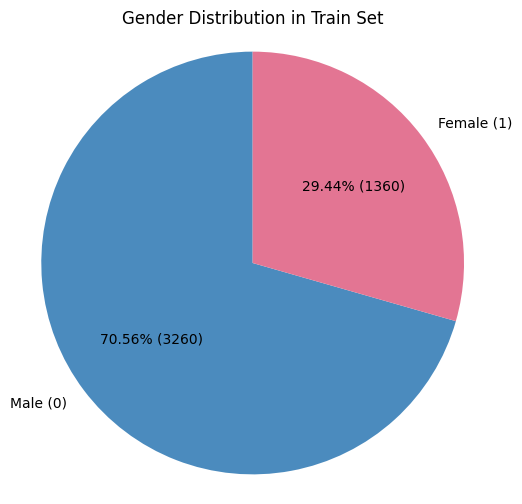

In [13]:
def autopct_format(pct):
    total = gender_counts.sum()
    val = int(round(pct * total / 100.0))
    return "{:.2f}% ({:d})".format(pct, val)


plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=labels,
    autopct=autopct_format,
    startangle=90,
    colors=["#4b8bbe", "#e37593"],
)
plt.title("Gender Distribution in Train Set")
plt.axis("equal")
plt.show()


 #  Model eğitimi (CNN + BiLSTM)
 **Log-mel**: UI tarafıyla aynı (realtime_gender_ui/audio_features.py).
  **3 saniye sabitleme**: canlı/stream’de her pencere model için sabit boyut olmalı.

 - Train: random crop (robustluk)
  - Val/Test: center crop (deterministik)
### Normalizasyon
**RMS normalize**: kayıt seviyeleri farklı olduğunda modelin “loudness” öğrenmesini azaltır.

### Dengesizlik (%70/%30)
 - **Sampler**: ya WeightedRandomSampler (utterance bazlı) ya da SpeakerBalancedSampler (speaker bazlı).
 - **Loss**: CrossEntropyLoss(weight=balanced) ile minority sınıfı güçlendirilir.

### Neden speaker-disjoint validation?
 Aynı konuşmacının hem train hem val’de olması, val skorunu yapay şişirebilir (speaker identity leakage).
 Bu nedenle train/val konuşmacıya göre ayrılır.

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Sampler

TARGET_SR = 16000
N_MELS = 80
HOP_LENGTH = 160
WIN_LENGTH = 400
FMIN, FMAX = 50, 7600

CLIP_SEC = 3.0
CLIP_SAMPLES = int(TARGET_SR * CLIP_SEC)
RMS_TARGET = 0.06

In [15]:
# PHN ile önce konuşma bölgesini al; sonra 3 s pencere (mikrofon/stream davranışına yakın)
USE_PHN_CROP = True
PHN_BUFFER_SAMPLES = 400

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)

In [16]:
def rms_normalize(y, target=RMS_TARGET):
    rms = np.sqrt(np.mean(y**2) + 1e-12)
    gain = target / (rms + 1e-12)
    y = y * gain
    y = np.clip(y, -1.0, 1.0)
    return y


In [ ]:
def _fixed_length_random(y: np.ndarray, train: bool) -> np.ndarray:
    if len(y) < CLIP_SAMPLES:
        y = np.pad(y, (0, CLIP_SAMPLES - len(y)))
    elif train:
         # Train’de random crop: konuşmanın farklı parçalarından öğrenme (genelleme artar).
        start = np.random.randint(0, len(y) - CLIP_SAMPLES + 1)
        y = y[start : start + CLIP_SAMPLES]
    else:
        # Val/Test’te center crop: aynı örnek → aynı feature (karşılaşt
        start = (len(y) - CLIP_SAMPLES) // 2
        y = y[start : start + CLIP_SAMPLES]
    return y

In [18]:
def load_wave_for_row(row, train: bool) -> np.ndarray:
    wav_path = row["wav_path"]
    if USE_PHN_CROP and "phn_segments_json" in row.index and pd.notna(row.get("phn_segments_json")):
        y = crop_wav_by_phn(wav_path, row["phn_segments_json"], buffer=PHN_BUFFER_SAMPLES, target_sr=TARGET_SR)
    else:
        y, _ = librosa.load(wav_path, sr=TARGET_SR, mono=True)
        y = y.astype(np.float32)
    y = rms_normalize(y)
    return _fixed_length_random(y, train=train)

In [19]:
def wav_to_logmel(y):
    S = librosa.feature.melspectrogram(
        y=y,
        sr=TARGET_SR,
        n_mels=N_MELS,
        n_fft=WIN_LENGTH,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0,
    )
    return librosa.power_to_db(S, ref=np.max).astype(np.float32)


In [20]:
class TimitGenderDataset(Dataset):
    def __init__(self, df, train=True, label_col="gender"):
        self.df = df.reset_index(drop=True)
        self.train = train
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = int(row[self.label_col])
        y = load_wave_for_row(row, train=self.train)
        feat = wav_to_logmel(y)
        x = torch.from_numpy(feat).unsqueeze(0)
        return x, torch.tensor(label, dtype=torch.long)


In [21]:
from sklearn.model_selection import train_test_split

if "speaker_id" in df_train.columns:
    speaker_major = (
        df_train.groupby("speaker_id")["gender"].agg(lambda s: s.value_counts().idxmax()).reset_index(name="major_label")
    )
    train_spk, val_spk = train_test_split(
        speaker_major["speaker_id"],
        test_size=0.2,
        random_state=RNG_SEED,
        stratify=speaker_major["major_label"],
    )
    train_spk, val_spk = set(train_spk), set(val_spk)
    df_tr = df_train[df_train["speaker_id"].isin(train_spk)].reset_index(drop=True)
    df_va = df_train[df_train["speaker_id"].isin(val_spk)].reset_index(drop=True)
else:
    df_tr, df_va = train_test_split(df_train, test_size=0.2, random_state=RNG_SEED, stratify=df_train["gender"])

 TIMIT’te her konuşmacının çok sayıda utterance’ı var.
 **Utterance-balanced sampler** bile bazen bazı konuşmacıları fazlaca gösterebilir.

 SpeakerBalancedSampler şunu hedefler:
 - Cinsiyet dengesini (%70/%30) **yakınsar**
 - Speaker çeşitliliğini artırır (Senaryo 2’deki konuşmacı geçişlerine daha iyi hazırlık)

 Bu, özellikle “dataset dışı konuşmacı” genellemesi için faydalıdır

 TIMIT'te her konuşmacının birden çok utterance'ı var.
 Bu sampler, her adımda önce cinsiyet (0/1), sonra konuşmacı, sonra utterance seçer.
 Böylece hem cinsiyet dengesizliği azalır hem de speaker-overfit riski düşer.

In [22]:
USE_SPEAKER_BALANCED_SAMPLER = True

In [ ]:
class SpeakerBalancedSampler(Sampler[int]):
    def __init__(self, df: pd.DataFrame, speaker_col: str = "speaker_id", label_col: str = "gender", seed: int = 42):
        self.df = df.reset_index(drop=True)
        self.speaker_col = speaker_col
        self.label_col = label_col
        self.rng = np.random.default_rng(seed)

        # konuşmacı -> indeksler
        self.spkr_to_idx: dict[str, np.ndarray] = {}
        for spk, g in self.df.groupby(self.speaker_col).groups.items():
            self.spkr_to_idx[str(spk)] = np.fromiter(g, dtype=np.int64)

        # konuşmacı -> etiket (çoğunluk)
        spk_label = (
            self.df.groupby(self.speaker_col)[self.label_col]
            .agg(lambda s: int(s.value_counts().idxmax()))
            .to_dict()
        )
        self.speakers_by_label: dict[int, list[str]] = {0: [], 1: []}
        for spk, lab in spk_label.items():
            if int(lab) in (0, 1):
                self.speakers_by_label[int(lab)].append(str(spk))

        # konuşmacı -> etiket (çoğunluk): bazı edge-case'lerde bir konuşmacı içindeki etiketler bozuksa koruma sağlar.
        self.all_speakers = list(self.spkr_to_idx.keys())

    def __len__(self) -> int:
        return len(self.df)

    def __iter__(self):
        for _ in range(len(self.df)):
            # mümkünse etiket dengeli (cinsiyet dengesi) seçim yap
            if self.speakers_by_label[0] and self.speakers_by_label[1]:
                lab = int(self.rng.integers(0, 2))
                spk = self.rng.choice(self.speakers_by_label[lab])
            else:
                spk = self.rng.choice(self.all_speakers)
            idxs = self.spkr_to_idx[spk]
            yield int(self.rng.choice(idxs))

In [24]:
# Varsayılan: dengesizliği azaltmak için speaker-balanced sampler (istersen kapat)
if USE_SPEAKER_BALANCED_SAMPLER and "speaker_id" in df_tr.columns:
    sampler = SpeakerBalancedSampler(df_tr, speaker_col="speaker_id", label_col="gender", seed=RNG_SEED)
    print("Sampler: SpeakerBalancedSampler (gender+speaker balanced)")
else:
    y_tr = df_tr["gender"].astype(int).values
    cc = np.bincount(y_tr, minlength=2)
    cw = 1.0 / (cc + 1e-12)
    sw = cw[y_tr]
    sampler = WeightedRandomSampler(torch.from_numpy(sw).double(), num_samples=len(sw), replacement=True)
    print("Sampler: WeightedRandomSampler")
    print("train class_counts:", cc, "train class_weights (sampler):", cw)

len(df_tr), len(df_va)

Sampler: SpeakerBalancedSampler (gender+speaker balanced)


(3690, 930)

In [25]:
# %%
class CNNBiLSTM(nn.Module):
    """realtime_gender_ui.CNNBiLSTM ile uyumlu (n_mels=80)."""

    def __init__(self, n_mels: int = 80, n_classes: int = 2):
        super().__init__()
        self._n_mels = n_mels
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),
        )
        self.lstm = nn.LSTM(
            input_size=64 * (n_mels // 8),
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.head = nn.Sequential(
            nn.Linear(128 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        z = self.cnn(x)
        b, c, fp, tp = z.shape
        z = z.permute(0, 3, 1, 2).contiguous().view(b, tp, c * fp)
        z, _ = self.lstm(z)
        z = z.mean(dim=1)
        return self.head(z)

In [26]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-3
WEIGHT_DECAY = 1e-2
EARLY_STOP_PATIENCE = 6
CLIP_GRAD = 3.0


 ## Kayıp ve metrikler

 - **Loss:** Balanced CrossEntropy.
 - **Metrikler:** accuracy + balanced_accuracy + macro-F1.
   Dengesiz dağılımda macro-F1 ve balanced accuracy daha “adil” sinyal verir.


In [27]:
# Sınıf ağırlıklı kayıp (balanced): sklearn ile aynı mantık n_samples / (n_classes * count)
from sklearn.utils.class_weight import compute_class_weight

_cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=df_tr["gender"].astype(int).values)
ce_weight = torch.tensor(_cw, dtype=torch.float32, device=device)

CHECKPOINT_PATH = Path(r"C:\Users\engin\Desktop\TIMIT\code\cnn_bilstm_gender_best.pt")


In [28]:
model = CNNBiLSTM(n_mels=N_MELS, n_classes=2).to(device)
train_ds = TimitGenderDataset(df_tr, train=True, label_col="gender")
val_ds = TimitGenderDataset(df_va, train=False, label_col="gender")
test_ds = TimitGenderDataset(df_test, train=False, label_col="gender")


In [29]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=(device == "cuda"))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device == "cuda"))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device == "cuda"))


In [30]:
criterion = nn.CrossEntropyLoss(weight=ce_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)


In [31]:
def run_epoch(loader, train=True):
    model.train(train)
    all_y, all_p = [], []
    total_loss = 0.0
    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        if train:
            optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
            optimizer.step()
        total_loss += float(loss.item()) * x.size(0)
        pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_p.extend(pred.tolist())
        all_y.extend(y.detach().cpu().numpy().tolist())
    avg_loss = total_loss / max(1, len(all_y))
    acc = accuracy_score(all_y, all_p)
    bacc = balanced_accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average="macro")
    return avg_loss, acc, bacc, f1m


In [32]:
best_val_f1 = -1.0
epochs_no_improve = 0


In [33]:
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_bacc, tr_f1 = run_epoch(train_loader, train=True)
    va_loss, va_acc, va_bacc, va_f1 = run_epoch(val_loader, train=False)
    scheduler.step(va_f1)
    print(
        f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} bacc {tr_bacc:.3f} f1(m) {tr_f1:.3f} | "
        f"val loss {va_loss:.4f} acc {va_acc:.3f} bacc {va_bacc:.3f} f1(m) {va_f1:.3f}"
    )
    if va_f1 > best_val_f1:
        best_val_f1 = va_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> kaydedildi: {CHECKPOINT_PATH} (val macro-F1={best_val_f1:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"Erken durdurma ({EARLY_STOP_PATIENCE} epoch iyileşme yok).")
            break

Epoch 01 | train loss 0.1213 acc 0.938 bacc 0.938 f1(m) 0.938 | val loss 0.0483 acc 0.985 bacc 0.975 f1(m) 0.981
  -> kaydedildi: C:\Users\engin\Desktop\TIMIT\code\cnn_bilstm_gender_best.pt (val macro-F1=0.9815)


Epoch 02 | train loss 0.0388 acc 0.986 bacc 0.986 f1(m) 0.986 | val loss 0.0261 acc 0.991 bacc 0.986 f1(m) 0.989
  -> kaydedildi: C:\Users\engin\Desktop\TIMIT\code\cnn_bilstm_gender_best.pt (val macro-F1=0.9895)


Epoch 03 | train loss 0.0252 acc 0.991 bacc 0.991 f1(m) 0.991 | val loss 0.0212 acc 0.994 bacc 0.989 f1(m) 0.992
  -> kaydedildi: C:\Users\engin\Desktop\TIMIT\code\cnn_bilstm_gender_best.pt (val macro-F1=0.9921)


Epoch 04 | train loss 0.0165 acc 0.995 bacc 0.995 f1(m) 0.995 | val loss 0.0117 acc 0.998 bacc 0.996 f1(m) 0.997
  -> kaydedildi: C:\Users\engin\Desktop\TIMIT\code\cnn_bilstm_gender_best.pt (val macro-F1=0.9974)


Epoch 05 | train loss 0.0105 acc 0.996 bacc 0.996 f1(m) 0.996 | val loss 0.0112 acc 0.998 bacc 0.996 f1(m) 0.997


Epoch 06 | train loss 0.0207 acc 0.992 bacc 0.992 f1(m) 0.992 | val loss 0.0498 acc 0.984 bacc 0.972 f1(m) 0.980


Epoch 07 | train loss 0.0186 acc 0.992 bacc 0.992 f1(m) 0.992 | val loss 0.0187 acc 0.995 bacc 0.991 f1(m) 0.993


Epoch 08 | train loss 0.0091 acc 0.996 bacc 0.996 f1(m) 0.996 | val loss 0.0250 acc 0.994 bacc 0.989 f1(m) 0.992


Epoch 09 | train loss 0.0046 acc 0.998 bacc 0.998 f1(m) 0.998 | val loss 0.0179 acc 0.996 bacc 0.993 f1(m) 0.995


Epoch 10 | train loss 0.0055 acc 0.998 bacc 0.998 f1(m) 0.998 | val loss 0.0168 acc 0.995 bacc 0.991 f1(m) 0.993
Erken durdurma (6 epoch iyileşme yok).


In [34]:
# Test + rapor (konfüzyon matrisi, sınıf bazlı F1)
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [35]:
_ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(_ckpt)
model.eval()
all_y, all_p = [], []
test_loss_total = 0.0
n_test = 0
with torch.no_grad():
    for x, y in tqdm(test_loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        test_loss_total += float(loss.item()) * x.size(0)
        n_test += x.size(0)
        preds = logits.argmax(1)
        all_y.extend(y.cpu().numpy().tolist())
        all_p.extend(preds.cpu().numpy().tolist())

te_loss = test_loss_total / max(1, n_test)
te_acc = accuracy_score(all_y, all_p)
te_bacc = balanced_accuracy_score(all_y, all_p)
te_f1m = f1_score(all_y, all_p, average="macro")
te_f1_w = f1_score(all_y, all_p, average="weighted")

In [36]:
print(f"TEST | loss {te_loss:.4f} acc {te_acc:.3f} balanced_acc {te_bacc:.3f} f1(macro) {te_f1m:.3f} f1(weighted) {te_f1_w:.3f}")
print(classification_report(all_y, all_p, target_names=["Male (0)", "Female (1)"]))


TEST | loss 0.1055 acc 0.985 balanced_acc 0.982 f1(macro) 0.983 f1(weighted) 0.985
              precision    recall  f1-score   support

    Male (0)       0.99      0.99      0.99      1120
  Female (1)       0.98      0.97      0.98       560

    accuracy                           0.99      1680
   macro avg       0.98      0.98      0.98      1680
weighted avg       0.99      0.99      0.99      1680



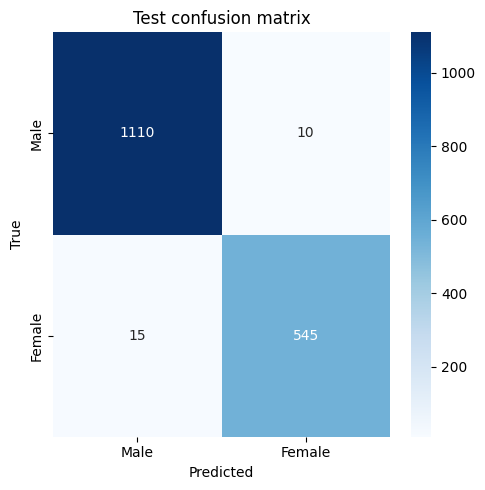

In [37]:
cm = confusion_matrix(all_y, all_p)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test confusion matrix")
plt.tight_layout()
plt.show()

In [38]:
# Konuşmacı düzeyinde çoğunluk oyu (her speaker için tahmin modu vs gerçek cinsiyet)
df_pred = df_test.reset_index(drop=True).copy()
assert len(all_p) == len(df_pred)
df_pred["_pred"] = all_p
speaker_hits = []
for _, g in df_pred.groupby("speaker_id"):
    true_g = int(g["gender"].iloc[0])
    mode = g["_pred"].mode()
    pred_maj = int(mode.iloc[0]) if len(mode) else int(g["_pred"].iloc[0])
    speaker_hits.append(1.0 if pred_maj == true_g else 0.0)
speaker_level_acc = float(np.mean(speaker_hits)) if speaker_hits else 0.0
print(f"Utterance-level accuracy: {te_acc:.4f}")
print(f"Speaker-level accuracy (majority vote): {speaker_level_acc:.4f}")

Utterance-level accuracy: 0.9851
Speaker-level accuracy (majority vote): 0.9881


In [39]:
import os
models_dir = "models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "model.pt")
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to models\model.pt
